# HW4 Q9 – One-Sided Hypothesis Test for a Crooked Die

**Reference:** *Think Stats* Ch. 9, Section 9.6

## Setup

A die is rolled **60 times**. Under a fair die, each face has probability 1/6, so the expected count per face is 10.

**Observed data:** face 3 came up **19 times** out of 60 rolls.

---

## Part (a) – Test Statistic

The book's two-sided statistic is:
$$T_{\text{two-sided}} = \sum_i |\text{observed}_i - \text{expected}_i|$$
This detects *any* deviation from a fair die.

For the **more specific** hypothesis that the die is biased *toward* 3, we care only about whether face 3 appears **more** than expected. An appropriate one-sided test statistic is:
$$\boxed{T = \text{observed count of 3} - \text{expected count of 3}}$$
which equals $19 - 10 = 9$ in our case. Large positive values of $T$ are evidence in favor of the alternative.

**Hypotheses:**  
$H_0$: die is fair ($p_3 = 1/6$)  
$H_1$: die is biased toward 3 ($p_3 > 1/6$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────────────────────────────
n_rolls  = 60
n_faces  = 6
face_of_interest = 3          # 1-indexed
observed_count_3 = 19
expected_count_3 = n_rolls / n_faces   # = 10.0

# ── Observed test statistic ────────────────────────────────────────────────
T_obs = observed_count_3 - expected_count_3
print(f"Observed count of 3 : {observed_count_3}")
print(f"Expected count of 3 : {expected_count_3:.1f}")
print(f"Test statistic T_obs: {T_obs}")

Observed count of 3 : 19
Expected count of 3 : 10.0
Test statistic T_obs: 9.0


## Part (b) – Simulation-Based p-value

Under $H_0$ (fair die) we simulate many sets of 60 rolls and record how often the count of 3 is at least as large as the observed count of 19.  The proportion of simulations where $T_{\text{sim}} \geq T_{\text{obs}}$ is our one-sided p-value.

In [2]:
np.random.seed(42)
N_SIM = 100_000

# Simulate N_SIM experiments: each is 60 rolls of a fair die
simulations = np.random.randint(1, n_faces + 1, size=(N_SIM, n_rolls))

# Count how many 3s appear in each simulated experiment
count_of_3 = (simulations == face_of_interest).sum(axis=1)

# Test statistic for each simulation
T_sim = count_of_3 - expected_count_3

# One-sided p-value: P(T_sim >= T_obs | H0)
p_value = np.mean(T_sim >= T_obs)

print(f"Number of simulations : {N_SIM:,}")
print(f"T_obs                 : {T_obs}")
print(f"p-value               : {p_value:.4f}")

Number of simulations : 100,000
T_obs                 : 9.0
p-value               : 0.0029


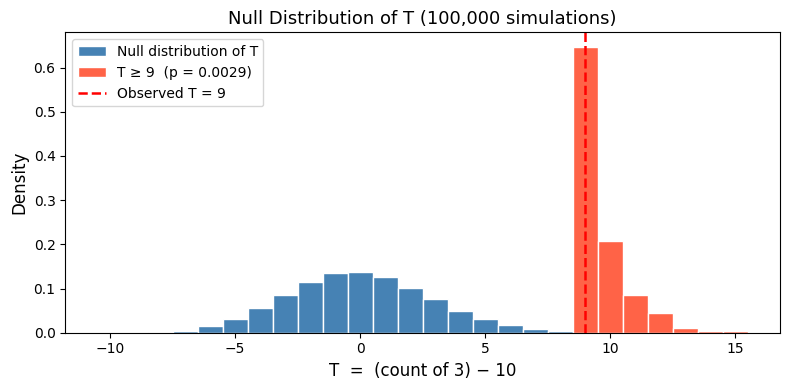

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = range(int(T_sim.min()), int(T_sim.max()) + 2)
ax.hist(T_sim, bins=bins, align='left', color='steelblue',
        edgecolor='white', density=True, label='Null distribution of T')
ax.hist(T_sim[T_sim >= T_obs],
        bins=range(int(T_obs), int(T_sim.max()) + 2),
        align='left', color='tomato', edgecolor='white',
        density=True, label=f'T ≥ {T_obs:.0f}  (p = {p_value:.4f})')
ax.axvline(T_obs, color='red', linestyle='--', linewidth=1.8,
           label=f'Observed T = {T_obs:.0f}')

ax.set_xlabel('T  =  (count of 3) − 10', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Null Distribution of T (100,000 simulations)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Summary

| | Value |
|---|---|
| Test statistic | $T = \text{count}(3) - 10$ |
| Observed $T$ | $19 - 10 = 9$ |
| Simulations | 100,000 |
| **p-value** | **≈ 0.0029** |

The p-value is approximately **0.29%**, well below $\alpha = 0.05$.  
We **reject $H_0$** and conclude there is statistically significant evidence that the die is biased toward landing on 3.

This p-value is smaller than what the two-sided statistic from Section 9.6 gives, illustrating the book's point: a more specific (one-sided) alternative yields a smaller p-value for the same data — but this is only valid when the direction of the alternative is chosen *before* seeing the data.